In [15]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

from scipy.stats import ks_2samp

from xgboost import XGBClassifier

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("datasets/improved_credit_risk.csv")

In [3]:
df.drop(columns=["Age"], inplace=True)

In [4]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

In [5]:
cat_cols = ["Payment_of_Min_Amount", "Credit_Mix", "Payment_Behaviour", "Borrower_Tier"]

df[cat_cols] = df[cat_cols].astype("category")

In [7]:
X = df.drop("Default_Flag", axis=1)
y = df["Default_Flag"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [10]:
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    n_estimators=300,
    learning_rate=0.05,
    enable_categorical=True,
    tree_method="hist",
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'auc'


In [13]:
y_pred_proba = model.predict_proba(X_test)[:,1]

roc_auc_score(y_test, y_pred_proba)

0.6132248544913028

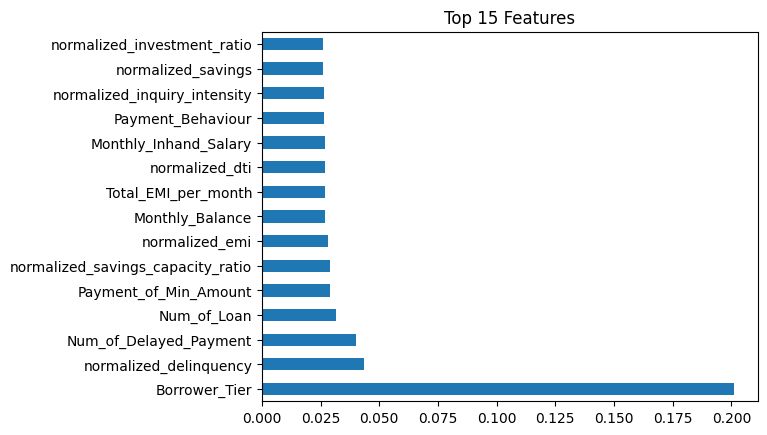

In [16]:
important_features = pd.Series(model.feature_importances_, index=X.columns)

important_features.nlargest(15).plot(kind="barh")
plt.title("Top 15 Features")

plt.show()